# 1D-CNN v8 -- All Scenarios (S1-S8)

In [1]:
# Cell 1: Import
import sys, math
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from config import RANDOM_SEED, N_CLASSES, MODELS_DIR, get_device
from src.experiment_runner import (
    get_splits, load_and_norm,
    run_zero_shot, run_calibration, print_comparison,
    TEST_SUBJECTS, TRAIN_SUBJECTS, META,
)
from src.evaluation import measure_latency, print_latency

torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
DEVICE = get_device()
splits = get_splits()
print(f'Device: {DEVICE}')

Device: mps


In [2]:
# Cell 2: Model
class ECA1d(nn.Module):
    def __init__(self,ch):
        super().__init__()
        k = max(int(abs(math.log2(ch)/2+0.5)),3); k = k if k%2 else k+1
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1,1,k,padding=k//2,bias=False)
    def forward(self,x):
        b,c,t = x.size()
        return x * torch.sigmoid(self.conv(self.gap(x).view(b,1,c))).view(b,c,1).expand_as(x)

class SepConv1d(nn.Module):
    def __init__(self,ic,oc,k=5,p=2):
        super().__init__()
        self.dw = nn.Conv1d(ic,ic,k,padding=p,groups=ic)
        self.pw = nn.Conv1d(ic,oc,1)
    def forward(self,x): return self.pw(self.dw(x))

class TemporalSCNN(nn.Module):
    def __init__(self,in_ch=8,n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch,64,5,padding=2), nn.BatchNorm1d(64), nn.ReLU(), ECA1d(64), nn.MaxPool1d(2),
            SepConv1d(64,128,5,2), nn.BatchNorm1d(128), nn.ReLU(), ECA1d(128), nn.MaxPool1d(2),
            SepConv1d(128,256,3,1), nn.BatchNorm1d(256), nn.ReLU(), ECA1d(256), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256,64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64,n_classes),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
    def forward(self,x): return self.classifier(self.features(x))
    def extract_feat(self,x):
        with torch.no_grad(): return nn.Flatten()(self.features(x))
    def extract_multiscale(self, x):
        with torch.no_grad():
            f1 = self.features[:5](x)
            f2 = self.features[5:10](f1)
            f3 = self.features[10:](f2)
            p1 = self.gap(f1).squeeze(-1)
            p2 = self.gap(f2).squeeze(-1)
            p3 = f3.squeeze(-1)
            return torch.cat([p1, p2, p3], dim=1)
print(f'Params: {sum(p.numel() for p in TemporalSCNN().parameters()):,}')

Params: 62,676


In [3]:
# Cell 3: Load model
train_combined = pd.concat([splits['train_df'], splits['s5_train']])
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f'Train: {X_train.shape}')

model = TemporalSCNN().to(DEVICE)
model.load_state_dict(torch.load(MODELS_DIR / '1dcnn_v6.pt', map_location=DEVICE))
model.eval()
print('Loaded 1dcnn_v6.pt')

Loading windows: 100%|██████████| 9021/9021 [00:07<00:00, 1269.05it/s]


Train: (1030712, 8, 50)
Loaded 1dcnn_v6.pt


In [4]:
# Cell 4: Base predict + features
@torch.no_grad()
def base_predict(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    return np.concatenate([model(xb[0].to(DEVICE)).argmax(1).cpu().numpy() for xb in loader])

@torch.no_grad()
def base_proba(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    probs = []
    for (xb,) in loader:
        probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
    return np.concatenate(probs)

@torch.no_grad()
def extract_features(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    return np.concatenate([model.extract_feat(xb[0].to(DEVICE)).cpu().numpy() for xb in loader])

@torch.no_grad()
def extract_multiscale(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    return np.concatenate([model.extract_multiscale(xb[0].to(DEVICE)).cpu().numpy() for xb in loader])

In [5]:
# Cell 5: Calibration (SVM ensemble + circular aug on cal)
def calibrate_svm(X_cal, y_cal):
    F_cal = extract_features(X_cal)
    X_rot = np.roll(X_cal, shift=1, axis=1)
    X_rot2 = np.roll(X_cal, shift=-1, axis=1)
    F_rot = extract_features(X_rot)
    F_rot2 = extract_features(X_rot2)
    F_all = np.vstack([F_cal, F_rot, F_rot2])
    y_all = np.concatenate([y_cal, y_cal, y_cal])
    sc = StandardScaler().fit(F_all)
    svm = SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=RANDOM_SEED)
    svm.fit(sc.transform(F_all), y_all)
    return svm, sc

def ensemble_predict(X, svm, sc, base_weight=0.3, cal_weight=0.7):
    p_base = base_proba(X)
    p_cal = svm.predict_proba(sc.transform(extract_features(X)))
    return (base_weight * p_base + cal_weight * p_cal).argmax(axis=1)

def cnn1d_finetune(X_cal, y_cal):
    svm, sc = calibrate_svm(X_cal, y_cal)
    def predict_ft(X): return ensemble_predict(X, svm, sc)
    return predict_ft

In [6]:
# Cell 6: S1-S5 Zero-shot
print('Option B -- Zero-shot:')
zero_results = run_zero_shot(base_predict, splits, norm_stats)

Option B -- Zero-shot:
  S1 zero-shot: 0.5862
  S2 zero-shot: 0.5352
  S3 zero-shot: 0.5398
  S4 zero-shot: 0.6556
  S5 zero-shot: 0.8029


In [7]:
# Cell 7: S1-S5 Calibrated
print('Option A -- Calibration:')
cal_results = run_calibration(base_predict, cnn1d_finetune, splits, norm_stats)

Option A -- Calibration:
  S1 calibrated: 0.7173
  S2 calibrated: 0.7673
  S3 calibrated: 0.8240
  S4 calibrated: 0.8228
  S5 calibrated: 0.8556


In [8]:
# Cell 8: S1-S5 Results
print_comparison(zero_results, cal_results, name='1D-CNN v8')


  1D-CNN v8 — RESULTS
Scenario        Zero-shot   Calibrated        Δ
-------------------------------------------------------
S1                58.62%       71.73%   +13.11%
S2                53.52%       76.73%   +23.22%
S3                53.98%       82.40%   +28.43%
S4                65.56%       82.28%   +16.71%
S5                80.29%       85.56% ✓   +5.27%


In [9]:
# Cell S6: Combined Factor
print('\n=== S6: Combined Factor (Cross-Subject + Shift) ===')
s6_test = META[(META['subject'].isin(TEST_SUBJECTS)) & (META['session']==0) & (META['position']>0)]
X_s6, y_s6, _ = load_and_norm(s6_test, stats=norm_stats)
s6_zs = accuracy_score(y_s6, base_predict(X_s6))
print(f'S6 zero-shot: {s6_zs:.4f}')

s6_cal_accs = []
for subj in TEST_SUBJECTS:
    sdf = s6_test[s6_test['subject']==subj]
    if len(sdf)==0: continue
    cal_df = sdf[sdf['repetition'].isin([0,1])]
    test_df = sdf[sdf['repetition']==2]
    if len(cal_df)==0 or len(test_df)==0: continue
    X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
    X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
    ft = cnn1d_finetune(X_c, y_c)
    acc = accuracy_score(y_t, ft(X_t))
    s6_cal_accs.append(acc)
    print(f'  {subj}: {acc:.4f}')
s6_cal = np.mean(s6_cal_accs)
print(f'S6 calibrated avg: {s6_cal:.4f}')


=== S6: Combined Factor (Cross-Subject + Shift) ===
S6 zero-shot: 0.5352
  h7: 0.9161
  h22: 0.8352
  h3: 0.8415
  h24: 0.8763
  h16: 0.9011
  h17: 0.8687
S6 calibrated avg: 0.8732



=== S7: Gradual Electrode Shift (h24-h29) ===
  Position  0: 0.7761
  Position  1: 0.8123
  Position  2: 0.7975
  Position  3: 0.8024
  Position  4: 0.7778
  Position  5: 0.8291
  Position  6: 0.8048
  Position  7: 0.7973
  Position  8: 0.7935
  Position  9: 0.8028
  Position 10: 0.7748

P0 baseline: 0.7761, Avg shifted: 0.7992, Degradation: -2.32%


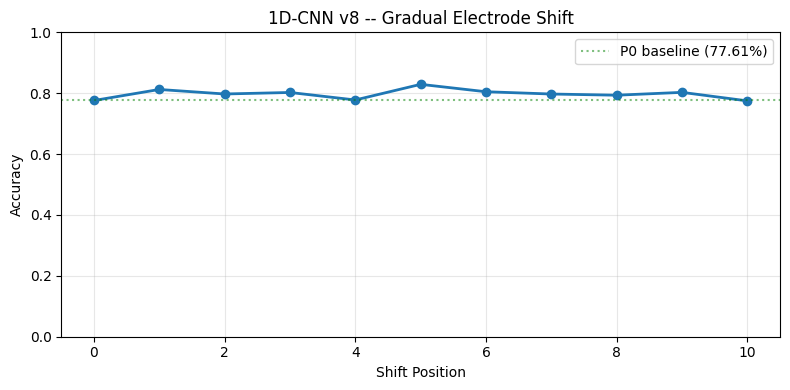

In [10]:
# Cell S7: Gradual Electrode Shift (h24-h29)
print('\n=== S7: Gradual Electrode Shift (h24-h29) ===')
shift_subjects = [f'h{i}' for i in range(24, 30)]
shift_data = META[(META['subject'].isin(shift_subjects)) & (META['session']==0)]

s7_acc = {}
for pos in sorted(shift_data['position'].unique()):
    pos_df = shift_data[shift_data['position']==pos]
    X_p, y_p, _ = load_and_norm(pos_df, stats=norm_stats)
    s7_acc[pos] = accuracy_score(y_p, base_predict(X_p))
    print(f'  Position {pos:2d}: {s7_acc[pos]:.4f}')

baseline = s7_acc.get(0, 0)
avg_shifted = np.mean([s7_acc[p] for p in s7_acc if p>0])
print(f'\nP0 baseline: {baseline:.4f}, Avg shifted: {avg_shifted:.4f}, Degradation: {(baseline-avg_shifted)*100:.2f}%')

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), 'o-', linewidth=2)
plt.axhline(y=baseline, color='green', ls=':', alpha=0.5, label=f'P0 baseline ({baseline:.2%})')
plt.xlabel('Shift Position'); plt.ylabel('Accuracy')
plt.title('1D-CNN v8 -- Gradual Electrode Shift')
plt.ylim(0, 1); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


=== S8: Few-Shot Calibration Analysis ===
  Zero-shot           : 0.5391  (~0 trials)
  1 rep, p0 only      : 0.5038  (~7 trials)
  1 rep, all pos      : 0.8242  (~77 trials)
  2 rep, p0 only      : 0.5313  (~14 trials)
  2 rep, all pos      : 0.8695  (~154 trials)


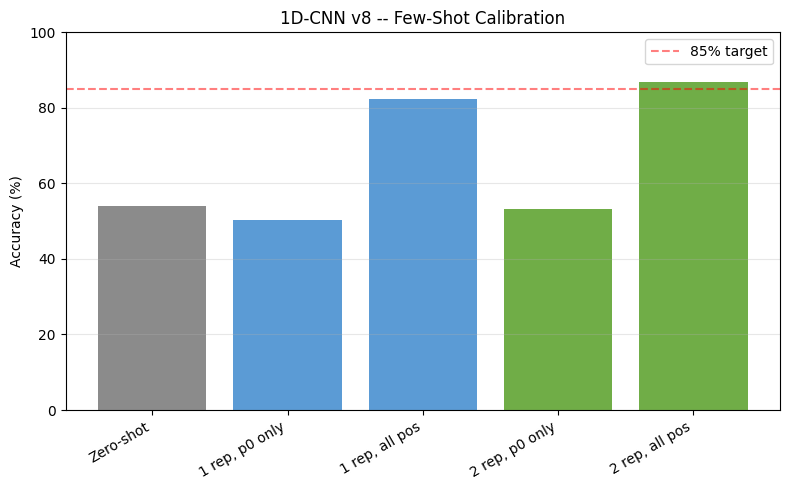

In [11]:
# Cell S8: Few-Shot Calibration Analysis
print('\n=== S8: Few-Shot Calibration Analysis ===')
subset_s8 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS))]

configs = [
    ('Zero-shot',        [],     False, 0),
    ('1 rep, p0 only',   [0],    True,  7),
    ('1 rep, all pos',   [0],    False, 77),
    ('2 rep, p0 only',   [0,1],  True,  14),
    ('2 rep, all pos',   [0,1],  False, 154),
]

s8_results = {}
for label, reps, p0_only, n_trials in configs:
    accs = []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8['subject']==subj]
        if len(reps)==0:
            X_t, y_t, _ = load_and_norm(sdf, stats=norm_stats)
            accs.append(accuracy_score(y_t, base_predict(X_t)))
            continue
        if p0_only:
            cal_df = sdf[(sdf['repetition'].isin(reps)) & (sdf['position']==0)]
        else:
            cal_df = sdf[sdf['repetition'].isin(reps)]
        test_df = sdf[sdf['repetition']==2]
        if len(cal_df)==0 or len(test_df)==0: continue
        X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
        X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
        ft = cnn1d_finetune(X_c, y_c)
        accs.append(accuracy_score(y_t, ft(X_t)))
    s8_results[label] = np.mean(accs)
    print(f'  {label:<20s}: {s8_results[label]:.4f}  (~{n_trials} trials)')

plt.figure(figsize=(8, 5))
labels = list(s8_results.keys())
vals = [v*100 for v in s8_results.values()]
bar_colors = ['#8B8B8B'] + ['#5B9BD5']*2 + ['#70AD47']*2
plt.bar(range(len(labels)), vals, color=bar_colors)
plt.axhline(y=85, color='red', ls='--', alpha=0.5, label='85% target')
plt.xticks(range(len(labels)), labels, rotation=30, ha='right')
plt.ylabel('Accuracy (%)'); plt.title('1D-CNN v8 -- Few-Shot Calibration')
plt.ylim(0, 100); plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.show()

In [12]:
# Cell: Latency
model.eval()
s = torch.randn(1,8,50).to(DEVICE)
for _ in range(10): _ = model(s)
if DEVICE.type=='mps': torch.mps.synchronize()
def _single(x):
    xt = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad(): out = model(xt)
    if DEVICE.type=='mps': torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()
latency = measure_latency(_single, X_train[:1], n_runs=500)
print_latency(latency, '1D-CNN v8')


Latency — 1D-CNN v8
  Mean:   1.27 ms
  Median: 1.20 ms
  P95:    1.30 ms
  <300ms: ✓


In [13]:
# Cell: Full Summary
print('\n' + '='*60)
print('  1D-CNN v8 -- FULL RESULTS')
print('='*60)
print(f'{"Scenario":<25} {"Zero-shot":>12} {"Calibrated":>12}')
print('-'*60)
for s in ['S1','S2','S3','S4','S5']:
    print(f'{s:<25} {zero_results[s]*100:>10.2f}%  {cal_results[s]*100:>10.2f}%')
print(f'{"S6 Combined":<25} {s6_zs*100:>10.2f}%  {s6_cal*100:>10.2f}%')
print(f'{"S7 Gradual (avg p1-10)":<25} {avg_shifted*100:>10.2f}%  {"--":>12}')
for label, val in s8_results.items():
    if label == 'Zero-shot': continue
    print(f'{"S8 " + label:<25} {"--":>12}  {val*100:>10.2f}%')
print(f'{"Latency p95 (ms)":<25} {latency["p95_ms"]:>10.2f}')
print(f'{"Parameters":<25} {"62,676":>12}')
print('='*60)


  1D-CNN v8 -- FULL RESULTS
Scenario                     Zero-shot   Calibrated
------------------------------------------------------------
S1                             58.62%       71.73%
S2                             53.52%       76.73%
S3                             53.98%       82.40%
S4                             65.56%       82.28%
S5                             80.29%       85.56%
S6 Combined                    53.52%       87.32%
S7 Gradual (avg p1-10)         79.92%            --
S8 1 rep, p0 only                   --       50.38%
S8 1 rep, all pos                   --       82.42%
S8 2 rep, p0 only                   --       53.13%
S8 2 rep, all pos                   --       86.95%
Latency p95 (ms)                1.30
Parameters                      62,676
